# מטלה בלמידת מכונה - ניתוח טקסט (NLP)
## סיווג קורות חיים לקטגוריות תפקידים

**פרטי הסטודנט:**
- Michel Kabir :שם
- ספרות אחרונות ת.ז.: 9164

---

## Datasetהסבר על הבעיה וה

.הבעיה היא **סיווג רב-מחלקתי** של קורות חיים  
(Multi-Class Classification)
.המטרה: לקרוא את טקסט קורות החיים ולנבא לאיזה **תחום תעסוקה** הם שייכים


Dataset **Updated Resume Dataset**  from Kaggle:  
https://www.kaggle.com/datasets/jillanisofttech/updated-resume-dataset

Dataset:
מכיל **2,484 קורות חיים** מ-25 קטגוריות שונות כמו:
Data Science, HR, Finance, Engineering ועוד.
זוהי בעיית סיווג רב-מחלקתית, לכן מדד האיכות שבו השתמשתי הוא:
**Macro-Average F1-Score**.

---

## AI Usage

I used Claude (Anthropic) for:
- Understanding the ML flow process for NLP problems
- Understanding the Naive Bayes algorithm and how to implement it
- Understanding TF-IDF and Bag of Words as feature engineering methods

All code was written and tested by me.

---
# DATASETחלק 1 טעינת ה

In [1]:
# ייבוא ספריות
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

print('!כל הספריות נטענו בהצלחה')

!כל הספריות נטענו בהצלחה


In [2]:
# datasetטעינת ה
df = pd.read_csv('UpdatedResumeDataSet.csv', encoding='utf-8', encoding_errors='ignore')

print(f'Total dataset size: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nNumber of categories: {df["Category"].nunique()}')
print(f'\nCategory distribution:')
print(df['Category'].value_counts())

df.head()

Total dataset size: (962, 2)

Columns: ['Category', 'Resume']

Number of categories: 25

Category distribution:
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: count, dtype: int64


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [3]:
# Split into train and test (80/20)
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['Category']
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train set size: {train_df.shape}')
print(f'Test set size:  {test_df.shape}')

print('\nFirst 5 rows of Train set:')
display(train_df.head())

print('\nFirst 5 rows of Test set:')
display(test_df.head())

Train set size: (769, 2)
Test set size:  (193, 2)

First 5 rows of Train set:


,Category,Resume
0,PMO,CORE COMPETENCIES â¢ Maintain processes to en...
1,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
2,Sales,Skill Sets: â¢ Multi-tasking â¢ Collaborativ...
3,Business Analyst,Education Details \r\n BE Computer Science Mum...
4,Java Developer,"TECHNICALSKILLS SpringMVC, Hibernate, JDBC, Ja..."



First 5 rows of Test set:


,Category,Resume
0,ETL Developer,Education Details \r\nJanuary 2015 Bachelor of...
1,Health and fitness,Education Details \r\nJanuary 2009 P.G. Sports...
2,Advocate,Education Details \r\nNovember 2016 to January...
3,Automation Testing,SOCIAL SKILLS: â¢ Ability to establish trust ...
4,Operations Manager,KEY COMPETENCIES â¶Multi - Operations Managem...


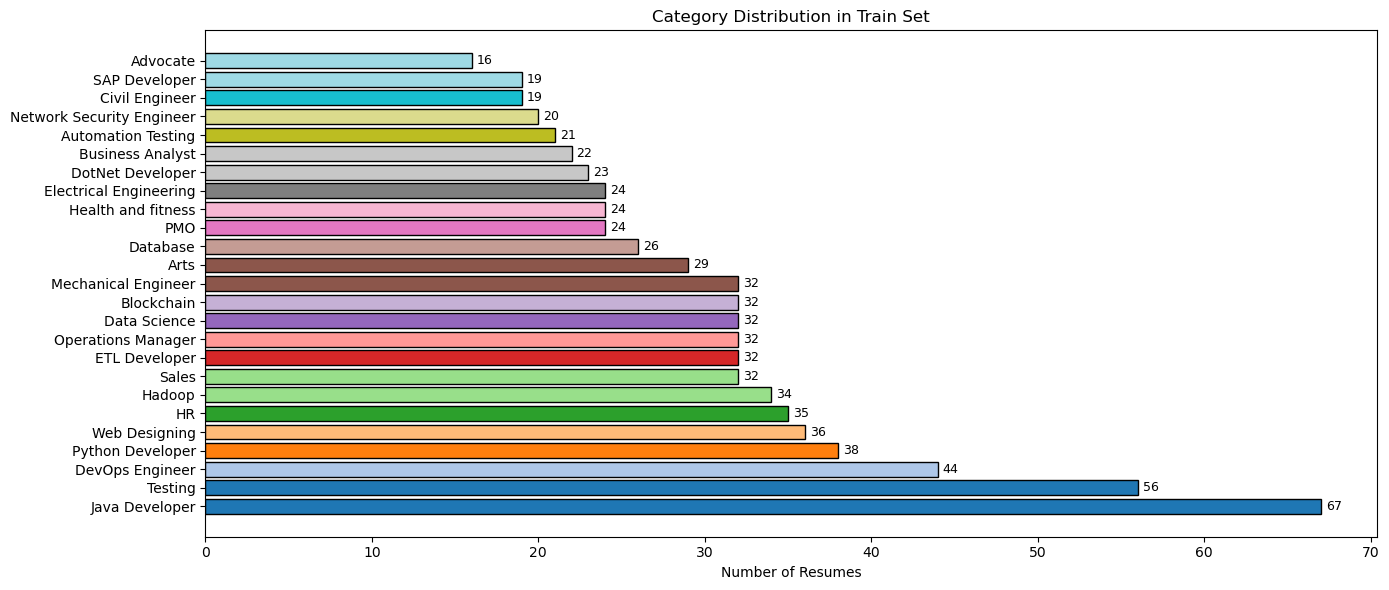

In [4]:
# ויזואליזציה : התפלגות הקטגוריות בTrain
fig, ax = plt.subplots(figsize=(14, 6))
counts = train_df['Category'].value_counts()
colors = plt.cm.tab20(np.linspace(0, 1, len(counts)))
bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='black')
ax.set_xlabel('Number of Resumes')
ax.set_title('Category Distribution in Train Set')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

---
# חלק 2: Feature Engineering

בניתוח טקסט (NLP) צריך להמיר את הטקסט לוקטור מספרי לפני שניתן לאמן מודל למידת מכונה.  
תהליך זה נקרא **Vectorization**.

נבצע עיבוד מוקדם (Preprocessing)
ואז נתנסה בשתי שיטות vectorization:
1. **Bag of Words** : סופר כמה פעמים כל מילה מופיעה בטקסט
2. **TF-IDF** : נותן משקל למילים לפי חשיבותן (מילים נדירות = חשובות יותר)

In [5]:
# פונקציית עיבוד מוקדם
def preprocess_text(text):
    """
    ניקוי טקסט קורת חיים:
    1. הסרת URLs
    2. הסרת סמלים מיוחדים
    3. המרה לאותיות קטנות
    4. הסרת פיסוק ומספרים
    5. הסרת רווחים מיותרים
    """
    # הסרת URLs
    text = re.sub(r'http\S+|www\S+', '', str(text))
    # הסרת סמלים מיוחדים (@, #, וכו')
    text = re.sub(r'[@#]\S+', '', text)
    # המרה לאותיות קטנות
    text = text.lower()
    # הסרת פיסוק
    text = text.translate(str.maketrans('', '', string.punctuation))
    # הסרת מספרים
    text = re.sub(r'\d+', '', text)
    # הסרת רווחים מיותרים
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# הפעלת הפונקציה
train_df['Resume_clean'] = train_df['Resume'].apply(preprocess_text)
test_df['Resume_clean']  = test_df['Resume'].apply(preprocess_text)

print('Examples before and after preprocessing:')
print('='*70)
for i in range(3):
    print(f'\nExample {i+1} [{train_df["Category"].iloc[i]}]:')
    print(f'  Before: {train_df["Resume"].iloc[i][:120]}...')
    print(f'  After:  {train_df["Resume_clean"].iloc[i][:120]}...')

Examples before and after preprocessing:

Example 1 [PMO]:
  Before: CORE COMPETENCIES â¢ Maintain processes to ensure project management documentation, reports and plans are relevant, acc...
  After:  core competencies â¢ maintain processes to ensure project management documentation reports and plans are relevant accur...

Example 2 [Data Science]:
  Before: Skills â¢ R â¢ Python â¢ SAP HANA â¢ Tableau â¢ SAP HANA SQL â¢ SAP HANA PAL â¢ MS SQL â¢ SAP Lumira â¢ C# â¢ ...
  After:  skills â¢ r â¢ python â¢ sap hana â¢ tableau â¢ sap hana sql â¢ sap hana pal â¢ ms sql â¢ sap lumira â¢ c â¢ l...

Example 3 [Sales]:
  Before: Skill Sets: â¢ Multi-tasking â¢ Collaborative â¢ Optimistic Thinking â¢ Effective teamleader/team trainer â¢ Visual...
  After:  skill sets â¢ multitasking â¢ collaborative â¢ optimistic thinking â¢ effective teamleaderteam trainer â¢ visualizi...


In [6]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Method 1: Bag of Words
bow_vec = CountVectorizer(max_features=5000, stop_words='english')
bow_vec.fit(train_df['Resume_clean'])   # fit on train only!

print('=== Bag of Words – 3 examples from Train ===')
for i in range(3):
    v = bow_vec.transform([train_df['Resume_clean'].iloc[i]])
    feat = bow_vec.get_feature_names_out()
    top = sorted(zip(feat, v.toarray()[0]), key=lambda x: x[1], reverse=True)[:5]
    print(f'\nExample {i+1} [{train_df["Category"].iloc[i]}]:')
    print(f'  Vector size: {v.shape[1]} dimensions, {v.nnz} non-zero values')
    print(f'  Top 5 words: {[(w, int(c)) for w,c in top]}')

print('\n=== Bag of Words – 3 examples from Test ===')
for i in range(3):
    v = bow_vec.transform([test_df['Resume_clean'].iloc[i]])
    print(f'\nExample {i+1} [{test_df["Category"].iloc[i]}]:')
    print(f'  Vector size: {v.shape[1]} dimensions, {v.nnz} non-zero values')

=== Bag of Words – 3 examples from Train ===

Example 1 [PMO]:
  Vector size: 5000 dimensions, 319 non-zero values
  Top 5 words: [('management', 12), ('project', 12), ('skills', 8), ('ability', 6), ('pune', 6)]

Example 2 [Data Science]:
  Vector size: 5000 dimensions, 285 non-zero values
  Top 5 words: [('data', 18), ('sap', 17), ('months', 16), ('analytics', 15), ('hana', 12)]

Example 3 [Sales]:
  Vector size: 5000 dimensions, 68 non-zero values
  Top 5 words: [('business', 3), ('details', 3), ('sales', 3), ('january', 2), ('leads', 2)]

=== Bag of Words – 3 examples from Test ===

Example 1 [ETL Developer]:
  Vector size: 5000 dimensions, 147 non-zero values

Example 2 [Health and fitness]:
  Vector size: 5000 dimensions, 103 non-zero values

Example 3 [Advocate]:
  Vector size: 5000 dimensions, 39 non-zero values


In [7]:
#  שיטה 2: TF-IDF 
tfidf_vec = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_vec.fit(train_df['Resume_clean'])   # fit on train only!

print('=== TF-IDF – 3 examples from Train ===')
for i in range(3):
    v = tfidf_vec.transform([train_df['Resume_clean'].iloc[i]])
    feat = tfidf_vec.get_feature_names_out()
    top = sorted(zip(feat, v.toarray()[0]), key=lambda x: x[1], reverse=True)[:5]
    print(f'\nExample {i+1} [{train_df["Category"].iloc[i]}]:')
    print(f'  Vector size: {v.shape[1]} dimensions')
    print(f'  Top 5 words by TF-IDF score: {[(w, round(s,3)) for w,s in top]}')

print('\n=== TF-IDF – 3 examples from Test ===')
for i in range(3):
    v = tfidf_vec.transform([test_df['Resume_clean'].iloc[i]])
    print(f'\nExample {i+1} [{test_df["Category"].iloc[i]}]:')
    print(f'  Vector size: {v.shape[1]} dimensions, {v.nnz} non-zero values')

=== TF-IDF – 3 examples from Train ===

Example 1 [PMO]:
  Vector size: 5000 dimensions
  Top 5 words by TF-IDF score: [('management', 0.186), ('project', 0.167), ('report', 0.167), ('dashboards', 0.166), ('ability', 0.164)]

Example 2 [Data Science]:
  Vector size: 5000 dimensions
  Top 5 words by TF-IDF score: [('sap', 0.358), ('hana', 0.332), ('analytics', 0.288), ('industry', 0.248), ('data', 0.177)]

Example 3 [Sales]:
  Vector size: 5000 dimensions
  Top 5 words by TF-IDF score: [('leads', 0.271), ('sales', 0.234), ('marketing', 0.197), ('business', 0.184), ('callmy', 0.172)]

=== TF-IDF – 3 examples from Test ===

Example 1 [ETL Developer]:
  Vector size: 5000 dimensions, 147 non-zero values

Example 2 [Health and fitness]:
  Vector size: 5000 dimensions, 103 non-zero values

Example 3 [Advocate]:
  Vector size: 5000 dimensions, 39 non-zero values


---
# חלק 3 – מימוש אלגוריתם Naive Bayes

## הסבר על האלגוריתם

**Naive Bayes** מבוסס על **משפט בייס**:

$$P(category | words) \propto P(category) \cdot \prod_{w} P(w | category)$$

**הרעיון:** אם קורת חיים מכילה מילים כמו `python`, `machine learning`, `tensorflow`   
הסיכוי שהיא שייכת לקטגוריית **Data Science** גבוה מאוד.

**ההנחה ה"נאיבית":** כל מילה עצמאית מהאחרות 

**Hyperparameter alpha (Laplace Smoothing):**  
מונע הסתברות אפס למילים שלא נראו באימון. ערך גבוה = החלקה חזקה יותר.

In [8]:
class NaiveBayesClassifier:
    """
    מימוש ידני של Multinomial Naive Bayes לסיווג טקסט.
    
    שלב אימון:
      - לומד P(category) : כמה נפוצה כל קטגוריה
      - לומד P(word|category) : כמה נפוצה כל מילה בכל קטגוריה
    
    שלב חיזוי:
      - מחשב log-probability לכל קטגוריה
      - מחזיר את הקטגוריה עם ההסתברות הגבוהה ביותר
    
    Hyperparameter:
      alpha: Laplace smoothing (ברירת מחדל=1.0)
    """
    
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.classes_ = None
        self.class_log_prior_ = {}
        self.feature_log_prob_ = {}
    
    def fit(self, X, y):
        X = np.array(X.todense())
        self.classes_ = np.unique(y)
        n_samples = X.shape[0]
        
        for c in self.classes_:
            X_c = X[y == c]
            # P(category) = שכיחות הקטגוריה בנתוני האימון
            self.class_log_prior_[c] = np.log(X_c.shape[0] / n_samples)
            # P(word|category) עם Laplace smoothing
            word_counts = X_c.sum(axis=0) + self.alpha
            self.feature_log_prob_[c] = np.log(word_counts / word_counts.sum())
        return self
    
    def predict_proba(self, X):
        X = np.array(X.todense())
        log_probs = np.array([
            self.class_log_prior_[c] + X.dot(self.feature_log_prob_[c])
            for c in self.classes_
        ]).T
        # המרה להסתברויות
        log_probs -= log_probs.max(axis=1, keepdims=True)
        probs = np.exp(log_probs)
        return probs / probs.sum(axis=1, keepdims=True)
    
    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


print('NaiveBayesClassifier class defined successfully!')
print(f'\nParameters:')
print('  alpha=0.1  → weak smoothing   (suitable for large datasets)')
print('  alpha=1.0  → standard smoothing (default)')
print('  alpha=2.0  → strong smoothing  (suitable for small datasets)')

NaiveBayesClassifier class defined successfully!

Parameters:
  alpha=0.1  → weak smoothing   (suitable for large datasets)
  alpha=1.0  → standard smoothing (default)
  alpha=2.0  → strong smoothing  (suitable for small datasets)


---
#  חלק 4 
# אימון + Grid Search + K-Fold Cross Validation

נבצע **Grid Search**  בדיקה של כל הצירופים האפשריים:
- Feature Engineering: BoW vs TF-IDF  
- Hyperparameter alpha: 0.1, 1.0, 2.0

עם **5-Fold Cross Validation** train מחלקים את ה
ל-5 חלקים בכל פעם, 4 לאימון ו-1 לוולידציה.

In [9]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score

feature_configs = {
    'Bag_of_Words': lambda: CountVectorizer(max_features=5000, stop_words='english'),
    'TF_IDF':       lambda: TfidfVectorizer(max_features=5000, stop_words='english'),
}
alpha_values = [0.1, 1.0, 2.0]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
print('Running Grid Search with 5-Fold Cross Validation...')
print('='*60)

for feat_name, vec_fn in feature_configs.items():
    for alpha in alpha_values:
        fold_scores = []
        for train_idx, val_idx in kf.split(train_df):
            fold_train = train_df.iloc[train_idx]
            fold_val   = train_df.iloc[val_idx]

            vec = vec_fn()
            X_tr  = vec.fit_transform(fold_train['Resume_clean'])
            X_val = vec.transform(fold_val['Resume_clean'])
            y_tr  = fold_train['Category'].values
            y_val = fold_val['Category'].values

            model = NaiveBayesClassifier(alpha=alpha)
            model.fit(X_tr, y_tr)
            y_pred = model.predict(X_val)

            score = f1_score(y_val, y_pred, average='macro')
            fold_scores.append(score)

        avg = np.mean(fold_scores)
        std = np.std(fold_scores)
        results.append({
            'Feature Engineering': feat_name,
            'Alpha': alpha,
            'Mean F1 (macro)': round(avg, 4),
            'Std F1': round(std, 4),
        })
        print(f'  {feat_name} | alpha={alpha} → F1={avg:.4f} ± {std:.4f}')

print('\nGrid Search complete!')

Running Grid Search with 5-Fold Cross Validation...
  Bag_of_Words | alpha=0.1 → F1=0.9893 ± 0.0056
  Bag_of_Words | alpha=1.0 → F1=0.9775 ± 0.0199
  Bag_of_Words | alpha=2.0 → F1=0.9635 ± 0.0215
  TF_IDF | alpha=0.1 → F1=0.9925 ± 0.0066
  TF_IDF | alpha=1.0 → F1=0.9034 ± 0.0252
  TF_IDF | alpha=2.0 → F1=0.7992 ± 0.0350

Grid Search complete!


In [10]:
# הצגת תוצאות
results_df = pd.DataFrame(results).sort_values('Mean F1 (macro)', ascending=False).reset_index(drop=True)
print('=== Grid Search Results – Sorted by F1 ===\n')
display(results_df)

best = results_df.iloc[0]
print(f'\n✅ Best combination:')
print(f'   Feature Engineering: {best["Feature Engineering"]}')
print(f'   Alpha:               {best["Alpha"]}')
print(f'   Mean F1 (macro):     {best["Mean F1 (macro)"]}')

=== Grid Search Results – Sorted by F1 ===



,Feature Engineering,Alpha,Mean F1 (macro),Std F1
0,TF_IDF,0.1,0.9925,0.0066
1,Bag_of_Words,0.1,0.9893,0.0056
2,Bag_of_Words,1.0,0.9775,0.0199
3,Bag_of_Words,2.0,0.9635,0.0215
4,TF_IDF,1.0,0.9034,0.0252
5,TF_IDF,2.0,0.7992,0.0350



✅ Best combination:
   Feature Engineering: TF_IDF
   Alpha:               0.1
   Mean F1 (macro):     0.9925


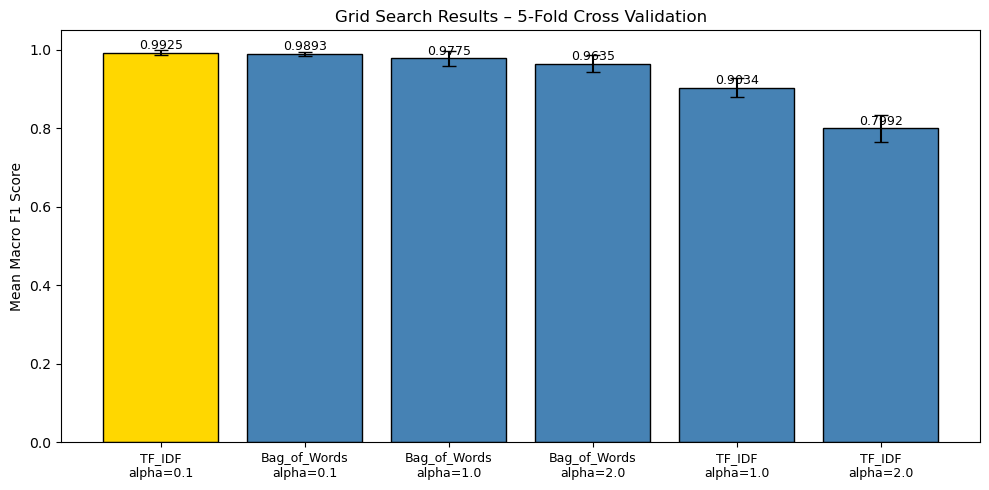

In [11]:
# ויזואליזציה של Grid Search
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = ax.bar(range(len(results_df)), results_df['Mean F1 (macro)'],
              color=colors, edgecolor='black')
ax.errorbar(range(len(results_df)), results_df['Mean F1 (macro)'],
            yerr=results_df['Std F1'], fmt='none', color='black', capsize=5)
labels = [f"{r['Feature Engineering']}\nalpha={r['Alpha']}" for _, r in results_df.iterrows()]
ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Mean Macro F1 Score')
ax.set_title('Grid Search Results – 5-Fold Cross Validation')
for bar, val in zip(bars, results_df['Mean F1 (macro)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('grid_search_results.png', dpi=100, bbox_inches='tight')
plt.show()

In [12]:
# אימון המודל הסופי על כל הTrain set
best_feat  = best['Feature Engineering']
best_alpha = best['Alpha']

final_vec = (CountVectorizer(max_features=5000, stop_words='english')
             if best_feat == 'Bag_of_Words'
             else TfidfVectorizer(max_features=5000, stop_words='english'))

X_train_full = final_vec.fit_transform(train_df['Resume_clean'])
y_train_full = train_df['Category'].values

final_model = NaiveBayesClassifier(alpha=best_alpha)
final_model.fit(X_train_full, y_train_full)

print(f'✅ Final model trained on {len(train_df)} resumes!')
print(f'   Feature Engineering: {best_feat}')
print(f'   Alpha: {best_alpha}')

# הצגת תהליך feature engineering על 3 דוגמאות מה-train
print('\n=== Feature Engineering Process – 3 examples from Train ===')
for i in range(3):
    msg   = train_df['Resume'].iloc[i]
    clean = train_df['Resume_clean'].iloc[i]
    label = train_df['Category'].iloc[i]
    v     = final_vec.transform([clean])
    print(f'\nExample {i+1} [{label}]:')
    print(f'  Original text: {msg[:80]}...')
    print(f'  After cleaning: {clean[:80]}...')
    print(f'  Vector: {v.shape[1]} dimensions, {v.nnz} non-zero values')

✅ Final model trained on 769 resumes!
   Feature Engineering: TF_IDF
   Alpha: 0.1

=== Feature Engineering Process – 3 examples from Train ===

Example 1 [PMO]:
  Original text: CORE COMPETENCIES â¢ Maintain processes to ensure project management documentat...
  After cleaning: core competencies â¢ maintain processes to ensure project management documentat...
  Vector: 5000 dimensions, 319 non-zero values

Example 2 [Data Science]:
  Original text: Skills â¢ R â¢ Python â¢ SAP HANA â¢ Tableau â¢ SAP HANA SQL â¢ SAP HANA P...
  After cleaning: skills â¢ r â¢ python â¢ sap hana â¢ tableau â¢ sap hana sql â¢ sap hana p...
  Vector: 5000 dimensions, 285 non-zero values

Example 3 [Sales]:
  Original text: Skill Sets: â¢ Multi-tasking â¢ Collaborative â¢ Optimistic Thinking â¢ Effe...
  After cleaning: skill sets â¢ multitasking â¢ collaborative â¢ optimistic thinking â¢ effect...
  Vector: 5000 dimensions, 68 non-zero values


---
# חלק 5 : חיזוי ושערוך איכות על Test Set

In [13]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Feature engineering on test set (transform only, no fit!)
X_test = final_vec.transform(test_df['Resume_clean'])
y_test = test_df['Category'].values

# Feature engineering process – 3 examples from Test
print('=== Feature Engineering Process – 3 examples from Test ===')
for i in range(3):
    msg   = test_df['Resume'].iloc[i]
    clean = test_df['Resume_clean'].iloc[i]
    label = test_df['Category'].iloc[i]
    v     = final_vec.transform([clean])
    print(f'\nExample {i+1} [{label}]:')
    print(f'  Original text: {msg[:80]}...')
    print(f'  After cleaning: {clean[:80]}...')
    print(f'  Vector: {v.shape[1]} dimensions, {v.nnz} non-zero values')

=== Feature Engineering Process – 3 examples from Test ===

Example 1 [ETL Developer]:
  Original text: Education Details 
January 2015 Bachelor of Engineering EXTC Mumbai, Maharashtr...
  After cleaning: education details january bachelor of engineering extc mumbai maharashtra mumbai...
  Vector: 5000 dimensions, 147 non-zero values

Example 2 [Health and fitness]:
  Original text: Education Details 
January 2009 P.G. Sports science  Dr. BMN College of Home Sc...
  After cleaning: education details january pg sports science dr bmn college of home science janua...
  Vector: 5000 dimensions, 103 non-zero values

Example 3 [Advocate]:
  Original text: Education Details 
November 2016 to January 2019 Llm Masters in Law Hyderabad, ...
  After cleaning: education details november to january llm masters in law hyderabad telangana sul...
  Vector: 5000 dimensions, 39 non-zero values


In [14]:
# חיזוי על Test
y_pred  = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)

print('=== First 5 Predictions on Test Set ===')
for i in range(5):
    true_label = y_test[i]
    pred_label = y_pred[i]
    pred_idx   = list(final_model.classes_).index(pred_label)
    confidence = y_proba[i][pred_idx]
    ok = '✅' if true_label == pred_label else '❌'
    print(f'\nExample {i+1} {ok}:')
    print(f'  True label:  {true_label}')
    print(f'  Prediction:  {pred_label}')
    print(f'  Confidence:  {confidence:.1%}')
    print(f'  Resume text: {test_df["Resume"].iloc[i][:80]}...')

=== First 5 Predictions on Test Set ===

Example 1 ✅:
  True label:  ETL Developer
  Prediction:  ETL Developer
  Confidence:  100.0%
  Resume text: Education Details 
January 2015 Bachelor of Engineering EXTC Mumbai, Maharashtr...

Example 2 ✅:
  True label:  Health and fitness
  Prediction:  Health and fitness
  Confidence:  100.0%
  Resume text: Education Details 
January 2009 P.G. Sports science  Dr. BMN College of Home Sc...

Example 3 ✅:
  True label:  Advocate
  Prediction:  Advocate
  Confidence:  96.8%
  Resume text: Education Details 
November 2016 to January 2019 Llm Masters in Law Hyderabad, ...

Example 4 ❌:
  True label:  Automation Testing
  Prediction:  Electrical Engineering
  Confidence:  51.0%
  Resume text: SOCIAL SKILLS: â¢ Ability to establish trust and work with a team. â¢ Determin...

Example 5 ✅:
  True label:  Operations Manager
  Prediction:  Operations Manager
  Confidence:  100.0%
  Resume text: KEY COMPETENCIES â¶Multi - Operations Managementâ¶People M

In [15]:
# מדדי איכות
f1_macro = f1_score(y_test, y_pred, average='macro')

print('='*55)
print('        Final Model Evaluation – Test Set')
print('='*55)
print(f'\nMacro-Average F1 Score: {f1_macro:.4f}')
print('\nDetailed classification report per category:')
print(classification_report(y_test, y_pred))

        Final Model Evaluation – Test Set

Macro-Average F1 Score: 0.9870

Detailed classification report per category:
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.80      0.80      0.80         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       0.86      1.00      0.92         6
        

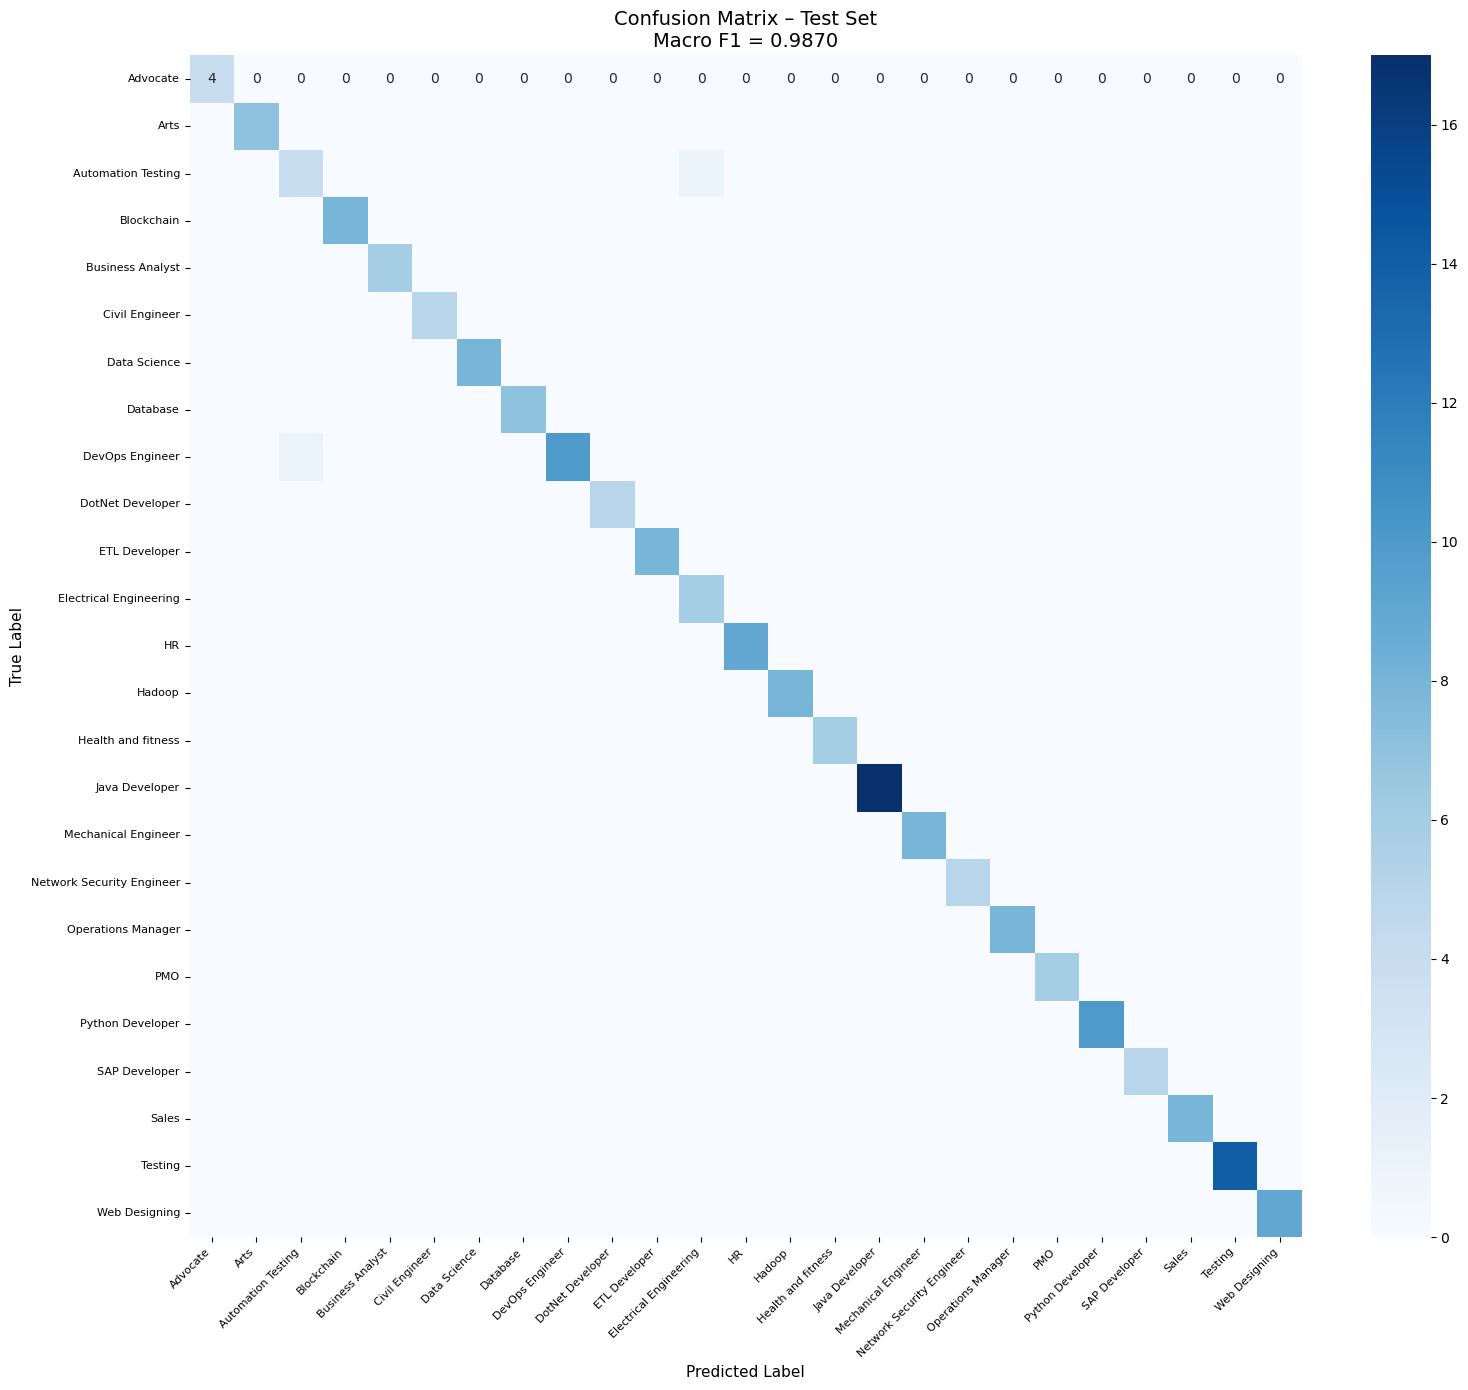

In [16]:
# Confusion Matrix
cats = sorted(final_model.classes_)
cm   = confusion_matrix(y_test, y_pred, labels=cats)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cats, yticklabels=cats, ax=ax)
ax.set_title(f'Confusion Matrix – Test Set\nMacro F1 = {f1_macro:.4f}', fontsize=14)
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

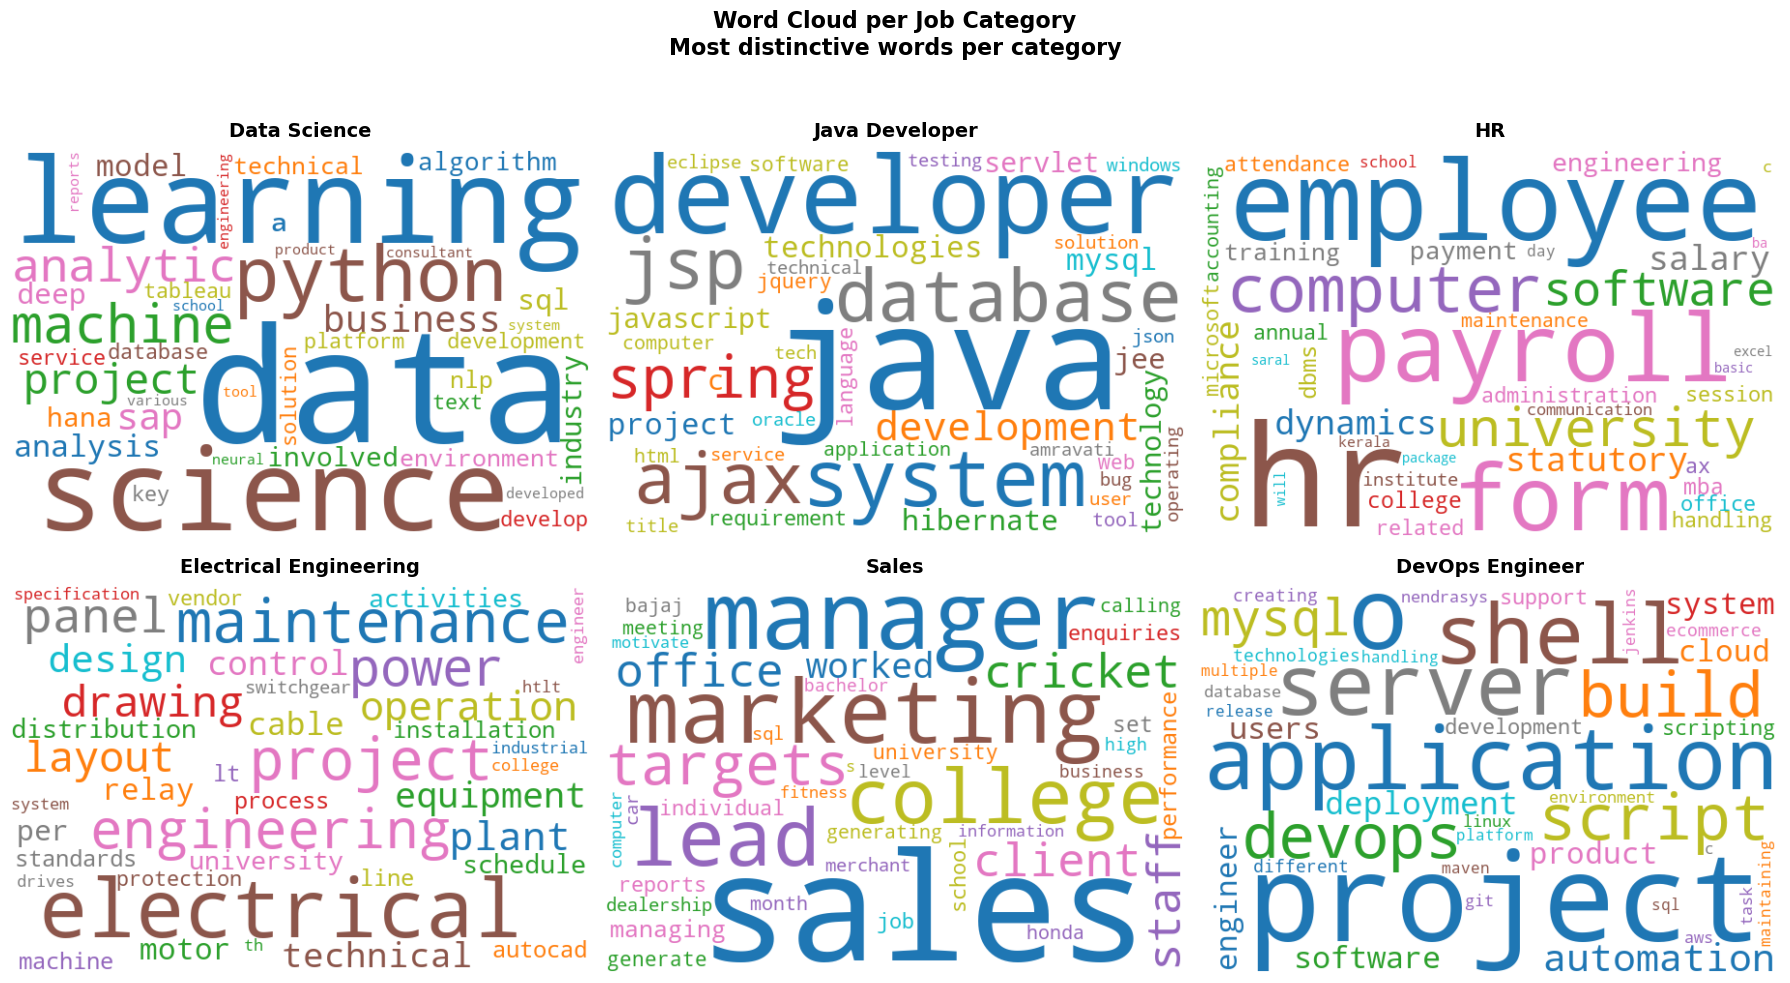

In [17]:
# Bonus – Word Cloud per Job Category (Final Version)
from wordcloud import WordCloud, STOPWORDS

# Combine built-in stopwords + our custom ones
custom_stopwords = STOPWORDS.union({
    'pvt', 'ltd', 'months', 'details', 'company', 'description',
    'experience', 'exprience', 'skill', 'skills', 'education',
    'year', 'years', 'work', 'working', 'knowledge', 'less',
    'january', 'february', 'march', 'april', 'june', 'july',
    'august', 'september', 'october', 'november', 'december',
    'responsibilities', 'role', 'team', 'management', 'completed',
    'pune', 'mumbai', 'india', 'maharashtra', 'monthscompany',
    'ms', 'using', 'used', 'ability', 'good', 'well', 'new',
    'â', 'ã', 'etc', 'also', 'one', 'two', 'three'
})

selected_categories = ['Data Science', 'Java Developer', 'HR', 
                       'Electrical Engineering', 'Sales', 'DevOps Engineer']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, category in enumerate(selected_categories):
    text = ' '.join(train_df[train_df['Category'] == category]['Resume_clean'].values)
    
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        max_words=40,
        colormap='tab10',
        random_state=42,
        stopwords=custom_stopwords,
        collocations=False
    ).generate(text)
    
    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(f'{category}', fontsize=14, fontweight='bold', pad=10)
    axes[idx].axis('off')

fig.suptitle('Word Cloud per Job Category\nMost distinctive words per category', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=100, bbox_inches='tight')
plt.show()

In [18]:
# סיכום סופי
print('='*60)
print('               סיכום הפרויקט')
print('='*60)
print(f'בעיה:           סיווג קורות חיים לקטגוריות תפקידים')
print(f'Dataset:        Updated Resume Dataset (Kaggle)')
print(f'קטגוריות:       {df["Category"].nunique()} קטגוריות שונות')
print(f'גודל train:     {len(train_df)} קורות חיים')
print(f'גודל test:      {len(test_df)} קורות חיים')
print(f'אלגוריתם:       Multinomial Naive Bayes (מימוש ידני)')
print(f'\nתוצאות Grid Search (5-Fold CV):')
display(results_df)
print(f'✅ Best model: {best_feat} + alpha={best_alpha}')
print(f'✅ Macro F1 on Test Set: {f1_macro:.4f}')

               סיכום הפרויקט
בעיה:           סיווג קורות חיים לקטגוריות תפקידים
Dataset:        Updated Resume Dataset (Kaggle)
קטגוריות:       25 קטגוריות שונות
גודל train:     769 קורות חיים
גודל test:      193 קורות חיים
אלגוריתם:       Multinomial Naive Bayes (מימוש ידני)

תוצאות Grid Search (5-Fold CV):


,Feature Engineering,Alpha,Mean F1 (macro),Std F1
0,TF_IDF,0.1,0.9925,0.0066
1,Bag_of_Words,0.1,0.9893,0.0056
2,Bag_of_Words,1.0,0.9775,0.0199
3,Bag_of_Words,2.0,0.9635,0.0215
4,TF_IDF,1.0,0.9034,0.0252
5,TF_IDF,2.0,0.7992,0.0350


✅ Best model: TF_IDF + alpha=0.1
✅ Macro F1 on Test Set: 0.9870
